<a href="https://colab.research.google.com/github/FrankArcosAnselmo/mI_lab01_Fa/blob/develop/LAB16_ARCOS_FRANK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Columnas del dataset
columnas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Cargar los archivos
df_train = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', header=None, names=columnas, na_values=' ?')
df_test = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test', skiprows=1, header=None, names=columnas, na_values=' ?')

# Eliminar puntos finales en income de test
df_test['income'] = df_test['income'].str.replace('.', '', regex=False)

# Unión de ambos datasets
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)

NameError: name 'np' is not defined

In [5]:
# Si hay puntos u otros, limpiar
df['income'] = df['income'].str.replace('.', '', regex=False).str.strip()

In [6]:
# Reemplazar '?' por NaN
df.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)

NameError: name 'np' is not defined

In [11]:
# Mostrar cantidad de datos faltantes
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [9]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

Paso 1: Preprocesamiento de Datos

1.1 Corrección de errores e imputación


In [10]:
# Verificar valores faltantes
df.isnull().sum()

# Imputar valores faltantes con la moda para variables categóricas
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-10-1248394459.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


# Tratamiento de outliers (univariado)



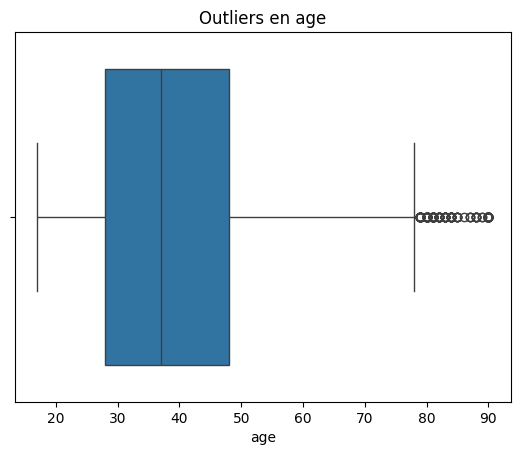

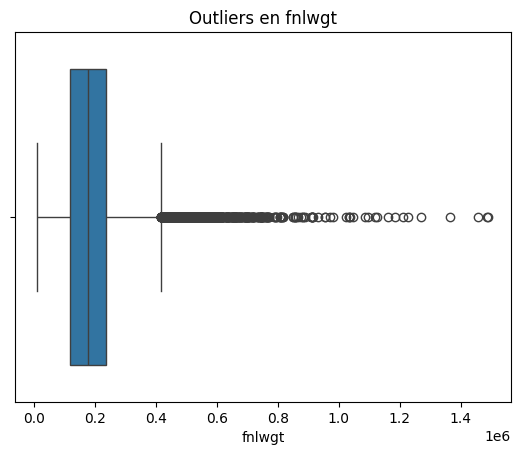

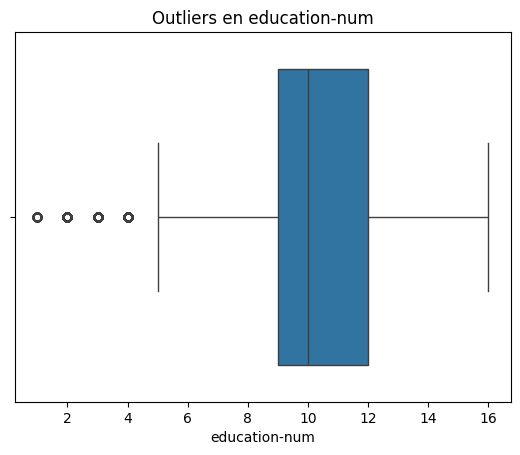

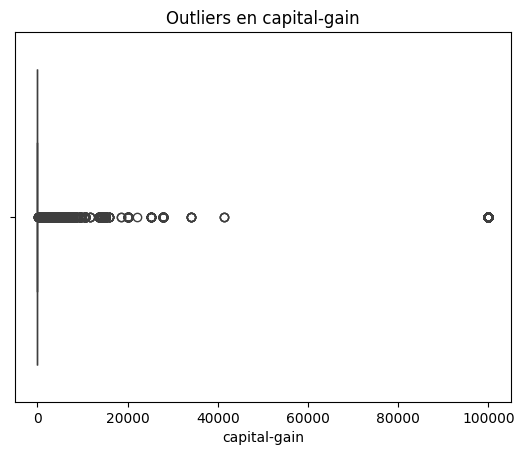

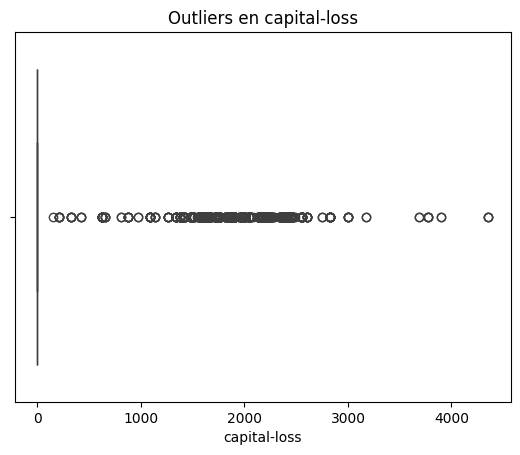

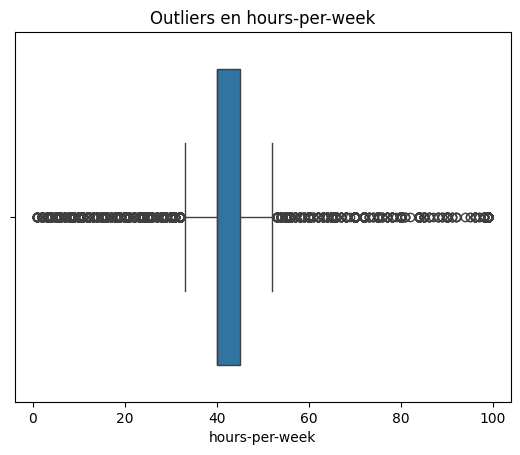

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots para detectar outliers
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Outliers en {col}")
    plt.show()

# Capping: limitar los valores extremos
for col in num_cols:
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(q1, q99)


## Outliers Multivariado



In [14]:
from scipy.stats import chi2
import numpy as np

def mahalanobis(x=None, data=None, cov=None):
    x_mu = x - np.mean(data)
    return np.dot(np.dot(x_mu, np.linalg.inv(cov)), x_mu.T)

data_num = df[num_cols]
cov_matrix = np.cov(data_num.values.T)
distances = data_num.apply(lambda row: mahalanobis(row, data_num, cov_matrix), axis=1)

# Eliminar registros con distancia Mahalanobis extrema
threshold = chi2.ppf(0.99, df=data_num.shape[1])
df = df[distances < threshold]


## Analsis de Correlacion

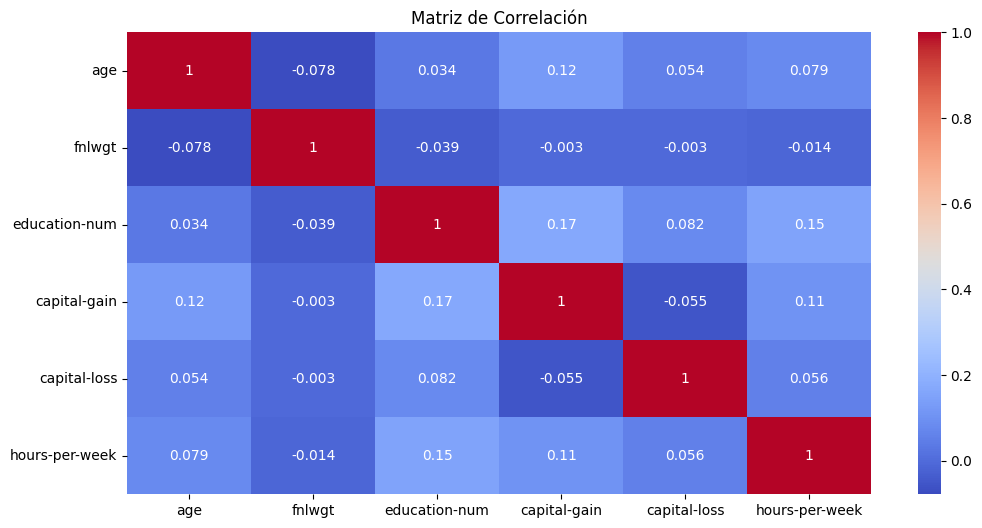

In [13]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()


B) Calcule el information value (IV) y seleccione las mejores variables, además, aplique un
escalamiento a las variables numéricas y convierta las variables categóricas a dummies. Separe
los datos en entrenamiento (80%) y prueba (20%) y realice un balanceo de clases

In [8]:
!pip install feature-engine
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import SelectByInformationValue

X = df.drop('income', axis=1)
y = df['income'].map({'>50K': 1, '<=50K': 0})  # binarizamos



In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2
import numpy as np
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import SelectByInformationValue
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

